# Seasonal surface water per Ethnologue polygon — yearly (2001+) FIXED version

Mirrors [`waterchange_seasonal_ethnologue_fixed.ipynb`](waterchange_seasonal_ethnologue_fixed.ipynb) (which produces year-2000 only) but loops over the **post-2000 yearly seasonal-water rasters** in `Water_surface/seasonal_water/`. Year 2000 is intentionally skipped because it's already produced by the year-2000 fixed notebook.

Tiles in the folder follow the naming pattern `seasonalwater_yh{YEAR}_100m_30m-*.tif` (one set of tiles per year, all in the same flat directory).

**Two corrections applied per year (same as the year-2000 fixed notebook):**

1. **Latitude-aware pixel area.** Each ~1 km cell's km² is computed from its latitude (spherical-Earth approximation), not flat `0.01`.
2. **Fraction-preserving aggregation.** After merging native binary tiles to ~1 km with `Resampling.average`, we keep the fractional values (share of native sub-pixels classified as seasonal water) instead of casting `> 0` to a binary 0/1.

**Output:** wide CSV with one column per year — `seasonalwater_y2001_km2`, `seasonalwater_y2002_km2`, ….

**Cost:** one merge per year (~21 merges).

In [2]:
import re
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterstats import zonal_stats

import matplotlib.pyplot as plt
from rasterio.plot import show

In [3]:
base_path     = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")
poscol_path   = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
water_path    = base_path / "maps" / "raw" / "Water_surface"
seasonal_dir  = water_path / "seasonal_water"

ethnologue = gpd.read_file(poscol_path)
ethnologue = ethnologue[["ID", "geometry"]]
print(f"Number of features: {len(ethnologue)}")

Number of features: 7087


In [4]:
# Discover which years are present in the folder
all_tifs = sorted(glob(str(seasonal_dir / "seasonalwater_yh*_100m_30m-*.tif")))
year_re = re.compile(r"seasonalwater_yh(\d{4})_")

files_by_year = {}
for fp in all_tifs:
    m = year_re.search(Path(fp).name)
    if not m:
        continue
    y = int(m.group(1))
    if y == 2000:
        continue   # year-2000 lives in the other fixed notebook
    files_by_year.setdefault(y, []).append(fp)

YEARS = sorted(files_by_year)
print(f"Years available (excluding 2000): {YEARS}")
for y in YEARS:
    print(f"  {y}: {len(files_by_year[y])} tiles")

Years available (excluding 2000): [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
  2001: 21 tiles
  2002: 21 tiles
  2003: 21 tiles
  2004: 21 tiles
  2005: 21 tiles
  2006: 21 tiles
  2007: 21 tiles
  2008: 21 tiles
  2009: 21 tiles
  2010: 21 tiles
  2011: 21 tiles
  2012: 21 tiles
  2013: 21 tiles
  2014: 21 tiles
  2015: 21 tiles
  2016: 21 tiles
  2017: 21 tiles
  2018: 21 tiles
  2019: 21 tiles
  2020: 21 tiles
  2021: 21 tiles


In [5]:
# --- Helpers (mirroring forestloss_ethnologue_fixed.ipynb) ----------------
def mosaic_1km_from_files(files):
    """Merge a given list of .tif tiles to ~1 km resolution using average resampling."""
    srcs = [rasterio.open(fp) for fp in files]
    mos, trans = merge(srcs, res=(0.01, 0.01), resampling=Resampling.average)
    crs = srcs[0].crs
    for s in srcs:
        s.close()
    return mos[0].astype(np.float32), trans, crs

def pixel_area_km2_grid(transform, shape):
    """(rows, cols) array of per-cell area in km² for an EPSG:4326 transform.
    Spherical-Earth approximation: cell area at latitude φ is
        (R * dλ * cosφ) * (R * dφ),  dλ, dφ in radians.
    """
    rows, cols = shape
    R_km  = 6371.0088
    dlat  = abs(transform.e)
    dlon  = abs(transform.a)
    lat_top = transform.f
    lat_centers = lat_top + (np.arange(rows) + 0.5) * transform.e
    lat_rad = np.deg2rad(lat_centers)
    dy_km = R_km * np.deg2rad(dlat)
    dx_km = R_km * np.cos(lat_rad) * np.deg2rad(dlon)
    area_row = (dx_km * dy_km).astype(np.float32)
    return np.broadcast_to(area_row[:, None], (rows, cols)).astype(np.float32)

def zonal_sum_on_array(array, transform, crs, polygons):
    """Write a float32 array to an in-memory GeoTIFF and zonal-sum it over `polygons`."""
    with MemoryFile() as mf:
        with mf.open(
            driver="GTiff",
            height=array.shape[0],
            width=array.shape[1],
            count=1,
            dtype="float32",
            transform=transform,
            crs=crs,
            nodata=np.float32(-9999.0),
        ) as dst:
            arr = np.where(np.isnan(array), np.float32(-9999.0), array).astype(np.float32)
            dst.write(arr, 1)
        stats = zonal_stats(polygons, mf.name, stats=["sum"], geojson_out=True)
    return [s["properties"]["sum"] for s in stats]

In [6]:
# Reproject Ethnologue polygons to match raster CRS (use first tile of first year as ref)
first_year = YEARS[0]
with rasterio.open(files_by_year[first_year][0]) as src0:
    raster_crs = src0.crs
ethnologue = ethnologue.to_crs(raster_crs)
print("Raster CRS:", raster_crs)

Raster CRS: EPSG:4326


Year 2001 mosaic shape: (17000, 36000) | crs: EPSG:4326
area_km2 range: 0.10785570740699768 - 1.2364345788955688 | mean: 0.8302695155143738


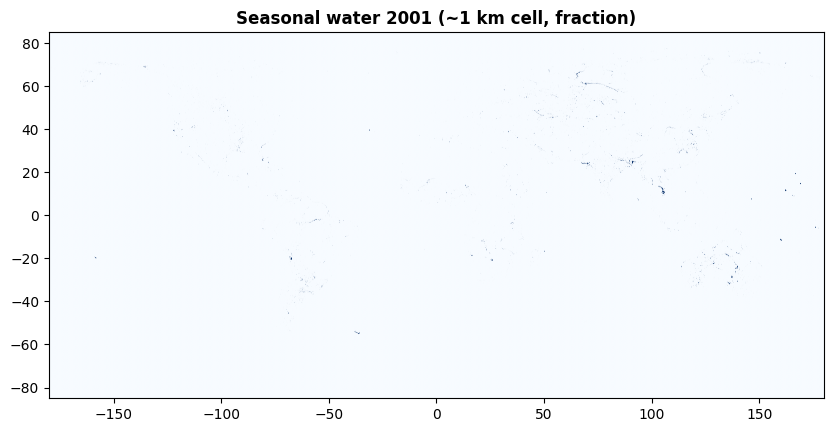

In [7]:
# --- Build first year mosaic, derive area grid, run first zonal sum ----------
frac_y, trans, crs = mosaic_1km_from_files(files_by_year[first_year])
print(f"Year {first_year} mosaic shape:", frac_y.shape, "| crs:", crs)

area_km2 = pixel_area_km2_grid(trans, frac_y.shape)
print("area_km2 range:", float(area_km2.min()), "-", float(area_km2.max()),
      "| mean:", float(area_km2.mean()))

fig, ax = plt.subplots(figsize=(10, 5))
show(frac_y, transform=trans, ax=ax,
     title=f"Seasonal water {first_year} (~1 km cell, fraction)",
     cmap="Blues", vmin=0, vmax=0.5)
plt.show()

In [8]:
# --- Loop over years, weighted-zonal-sum km² of seasonal water --------------
year_results = {}

weighted = (np.clip(frac_y, 0, 1) * area_km2).astype(np.float32)
year_results[first_year] = zonal_sum_on_array(weighted, trans, crs, ethnologue)
del weighted, frac_y
print(f"Done year {first_year}")

for y in YEARS[1:]:
    frac_y, trans_y, crs_y = mosaic_1km_from_files(files_by_year[y])
    assert trans_y == trans and crs_y == crs and frac_y.shape == area_km2.shape, \
        f"Inconsistent mosaic geometry for year {y}"
    weighted = (np.clip(frac_y, 0, 1) * area_km2).astype(np.float32)
    year_results[y] = zonal_sum_on_array(weighted, trans, crs, ethnologue)
    del frac_y, weighted
    print(f"Done year {y}")

Done year 2001
Done year 2002
Done year 2003
Done year 2004
Done year 2005
Done year 2006
Done year 2007
Done year 2008
Done year 2009
Done year 2010
Done year 2011
Done year 2012
Done year 2013
Done year 2014
Done year 2015
Done year 2016
Done year 2017
Done year 2018
Done year 2019
Done year 2020
Done year 2021


In [9]:
# Build wide dataframe: ID + seasonalwater_y{YEAR}_km2 columns
df = pd.DataFrame({"ID": ethnologue["ID"].values})
for y in sorted(year_results):
    df[f"seasonalwater_y{y}_km2"] = year_results[y]

year_cols = [c for c in df.columns if c.startswith("seasonalwater_y")]
print(len(df))
df[["ID"] + year_cols[:5]].head()

7087


,ID,seasonalwater_y2001_km2,seasonalwater_y2002_km2,seasonalwater_y2003_km2,seasonalwater_y2004_km2,seasonalwater_y2005_km2
0,RUS-RUS,30847.128906,30172.343750,16326.866211,19413.097656,20171.539062
1,ENG-USA,13118.143555,15720.374023,12740.264648,13655.053711,13504.552734
2,POR-BRA,16747.636719,16461.699219,13534.416016,13561.285156,16936.935547
3,ENG-AUS,23444.066406,9518.328125,15892.195312,26546.394531,15199.979492
4,CMN-CHN,15237.956055,14717.082031,16288.991211,13742.521484,14708.117188


In [10]:
# Quick descriptive table — see seasonal-water trajectory across years
df[year_cols].describe()

,seasonalwater_y2001_km2,seasonalwater_y2002_km2,seasonalwater_y2003_km2,seasonalwater_y2004_km2,seasonalwater_y2005_km2,seasonalwater_y2006_km2,seasonalwater_y2007_km2,seasonalwater_y2008_km2,seasonalwater_y2009_km2,seasonalwater_y2010_km2,...,seasonalwater_y2012_km2,seasonalwater_y2013_km2,seasonalwater_y2014_km2,seasonalwater_y2015_km2,seasonalwater_y2016_km2,seasonalwater_y2017_km2,seasonalwater_y2018_km2,seasonalwater_y2019_km2,seasonalwater_y2020_km2,seasonalwater_y2021_km2
count,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,...,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000,7057.000000
mean,45.443172,43.106936,37.298296,45.521201,44.848116,45.207311,51.803070,45.327485,45.734755,48.547224,...,37.831197,52.041471,53.751523,48.963497,63.532034,65.148754,62.797162,53.027387,64.771686,58.871783
std,661.743582,618.777381,496.402706,632.825406,580.900633,564.441103,754.658747,574.637207,636.088755,665.731797,...,468.727511,713.312003,732.481725,676.815192,946.546608,896.639870,858.440010,658.847882,890.645617,732.465456
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,30847.128906,30172.343750,16326.866211,26546.394531,20171.539062,19830.623047,38549.222656,19549.003906,26638.535156,30604.339844,...,17731.917969,39840.468750,36643.660156,35395.617188,53680.117188,46611.929688,49730.269531,26835.480469,53733.070312,39250.179688


In [11]:
# Sanity: compare 2001 column against the year-2000 fixed CSV as a basic check
y2000_csv = water_path / "ethnologue_seasonalwater_2000_fixed.csv"
if y2000_csv.exists() and 2001 in year_results:
    df_y2000 = pd.read_csv(y2000_csv)
    cmp = df[["ID", "seasonalwater_y2001_km2"]].merge(
        df_y2000[["ID", "seasonalwater_2000_km2"]], on="ID", how="left"
    )
    cmp["diff_2001_minus_2000"] = cmp["seasonalwater_y2001_km2"] - cmp["seasonalwater_2000_km2"]
    print(cmp[["seasonalwater_y2001_km2", "seasonalwater_2000_km2", "diff_2001_minus_2000"]].describe())
else:
    print("Year-2000 fixed CSV not found — skipping comparison.")

       seasonalwater_y2001_km2  seasonalwater_2000_km2  diff_2001_minus_2000
count              7057.000000             7057.000000           7057.000000
mean                 45.443172               44.628057              0.815115
std                 661.743582              661.678076            122.555962
min                   0.000000                0.000000          -4628.490234
25%                   0.000000                0.000000              0.000000
50%                   0.000000                0.000000              0.000000
75%                   0.000000                0.000000              0.000000
max               30847.128906            28072.556641           3862.878540


In [12]:
out_path = water_path / "ethnologue_seasonalwater_byyear_fixed.csv"
df.to_csv(out_path, index=False)
print("Exported", out_path)

Exported C:\Users\juami\Dropbox\RAships\2-Folklore-Nathan-Project\EA-Maps-Nathan-project\Measures_work\maps\raw\Water_surface\ethnologue_seasonalwater_byyear_fixed.csv
